Jovana Kovac
Eco 590
Pace University
Spring 2026

Research Question: What Determines Life Expectancy Across Countries?

Motivation:
Life expectancy is commonly used as a measure of overall health and economic well-being across countries. While wealthier countries often have greater access to healthcare resources, economic prosperity alone may not fully explain differences in life expectancy. Understanding which economic and health-related factors are associated with longer life expectancy can help provide insight into broader global inequalities in health outcomes.

Data Collection:
The data for this project was collected using the World Bank API in Python. The analysis focuses on observations from 2022 because this year provided the most complete and consistent data coverage across countries and variables after merging the datasets.

The variables I used in this project include life expectancy, GDP per capita, health expenditure per capita, and unemployment rate. 
A new variable, log GDP per capita, was also created for the regression analysis.

In [1]:
#Packages needed
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Life expectancy data from World Bank API
life_expectancy = requests.get("https://api.worldbank.org/v2/country/all/indicator/SP.DYN.LE00.IN?format=json&per_page=20000").json()

In [3]:
#The World Bank API contains metadata and country observations
#[1] selects the country observations

life_expectancy = pd.DataFrame(life_expectancy[1])
life_expectancy

,indicator,country,countryiso3code,date,value,unit,obs_status,decimal
0,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2025,NaN,,,0
1,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2024,65.349930,,,0
2,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2023,65.146228,,,0
3,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2022,64.487152,,,0
4,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'ZH', 'value': 'Africa Eastern and Sout...",AFE,2021,62.979999,,,0
...,...,...,...,...,...,...,...,...
17551,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'ZW', 'value': 'Zimbabwe'}",ZWE,1964,55.431000,,,0
17552,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'ZW', 'value': 'Zimbabwe'}",ZWE,1963,54.942000,,,0
17553,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'ZW', 'value': 'Zimbabwe'}",ZWE,1962,54.453000,,,0
17554,"{'id': 'SP.DYN.LE00.IN', 'value': 'Life expect...","{'id': 'ZW', 'value': 'Zimbabwe'}",ZWE,1961,53.966000,,,0


In [4]:
#The columns needed for analysis
life_expectancy = life_expectancy[['countryiso3code', 'country', 'date', 'value']]

In [5]:
#Country name from the dictionary column
life_expectancy.loc[:, 'country'] = life_expectancy['country'].str['value']

In [6]:
#Rename value column
life_expectancy = life_expectancy.rename(columns = {'value':'life_expectancy'})

In [8]:
#Keep observations from 2022 because this year had the most complete data coverage across variables and countries
life_expectancy = life_expectancy[life_expectancy['date'] == '2022']
life_expectancy

,countryiso3code,country,date,life_expectancy
3,AFE,Africa Eastern and Southern,2022,64.487152
69,AFW,Africa Western and Central,2022,57.987850
135,ARB,Arab World,2022,71.876096
201,CSS,Caribbean small states,2022,72.832292
267,CEB,Central Europe and the Baltics,2022,76.652299
...,...,...,...,...
17229,VIR,Virgin Islands (U.S.),2022,80.319512
17295,PSE,West Bank and Gaza,2022,76.662000
17361,YEM,"Yemen, Rep.",2022,67.952000
17427,ZMB,Zambia,2022,65.279000


In [9]:
#GDP per capita data from World Bank API
gdp = requests.get("https://api.worldbank.org/v2/country/all/indicator/NY.GDP.PCAP.CD?format=json&per_page=20000").json()

In [10]:
#[1] selects the country observations
gdp = pd.DataFrame(gdp[1])

In [11]:
#The columns needed for analysis
gdp = gdp[['countryiso3code', 'date', 'value']]

In [12]:
#Rename value column
gdp = gdp.rename(columns = {'value':'gdp_per_capita'})

In [13]:
#Keep observations from 2022
gdp = gdp[gdp['date'] == '2022']
gdp

,countryiso3code,date,gdp_per_capita
3,AFE,2022,1679.327622
69,AFW,2022,2138.473153
135,ARB,2022,7950.355820
201,CSS,2022,17456.308485
267,CEB,2022,19530.155323
...,...,...,...
17229,VIR,2022,44320.909186
17295,PSE,2022,3799.955270
17361,YEM,2022,NaN
17427,ZMB,2022,1447.123101


In [14]:
#Health expenditure data from World Bank API
health = requests.get("https://api.worldbank.org/v2/country/all/indicator/SH.XPD.CHEX.PC.CD?format=json&per_page=20000").json()

In [15]:
#[1] selects the country observations
health = pd.DataFrame(health[1])

In [16]:
#Keep columns needed for analysis
health = health[['countryiso3code', 'date', 'value']]

In [17]:
#Rename value column
health = health.rename(columns = {'value':'health_expenditure'})

In [18]:
#Keep observations from 2022
health = health[health['date'] == '2022']
health

,countryiso3code,date,health_expenditure
3,AFE,2022,92.035288
69,AFW,2022,74.441253
135,ARB,2022,348.767262
201,CSS,2022,915.955449
267,CEB,2022,1374.160069
...,...,...,...
17229,VIR,2022,NaN
17295,PSE,2022,350.638123
17361,YEM,2022,54.290363
17427,ZMB,2022,75.401283


In [19]:
#Unemployment rate data from World Bank API
unemployment = requests.get("https://api.worldbank.org/v2/country/all/indicator/SL.UEM.TOTL.ZS?format=json&per_page=20000").json()

In [20]:
#[1] selects the country observations
unemployment = pd.DataFrame(unemployment[1])

In [21]:
#Keep columns needed for analysis
unemployment = unemployment[['countryiso3code', 'date', 'value']]

In [22]:
#Rename value column
unemployment = unemployment.rename(columns = {'value':'unemployment_rate'})

In [23]:
#Keep observations from 2022
unemployment = unemployment[unemployment['date'] == '2022']

In [40]:
#Merging all the datasets together

world_data = pd.merge(life_expectancy, gdp, on = ['countryiso3code', 'date'])
world_data = pd.merge(world_data, health, on = ['countryiso3code', 'date'])
world_data = pd.merge(world_data, unemployment, on = ['countryiso3code', 'date']).copy()
world_data

,countryiso3code,country,date,life_expectancy,gdp_per_capita,health_expenditure,unemployment_rate
0,AFE,Africa Eastern and Southern,2022,64.487152,1679.327622,92.035288,7.869470
1,AFW,Africa Western and Central,2022,57.987850,2138.473153,74.441253,3.593354
2,ARB,Arab World,2022,71.876096,7950.355820,348.767262,9.744131
3,CSS,Caribbean small states,2022,72.832292,17456.308485,915.955449,8.298678
4,CEB,Central Europe and the Baltics,2022,76.652299,19530.155323,1374.160069,3.965406
...,...,...,...,...,...,...,...
881,VIR,Virgin Islands (U.S.),2022,80.319512,44320.909186,NaN,12.092000
882,PSE,West Bank and Gaza,2022,76.662000,3799.955270,350.638123,24.420000
883,YEM,"Yemen, Rep.",2022,67.952000,NaN,54.290363,17.224000
884,ZMB,Zambia,2022,65.279000,1447.123101,75.401283,5.993000


In [25]:
#Creating the new variable: log GDP per capita
world_data['log_gdp'] = np.log(world_data['gdp_per_capita'])

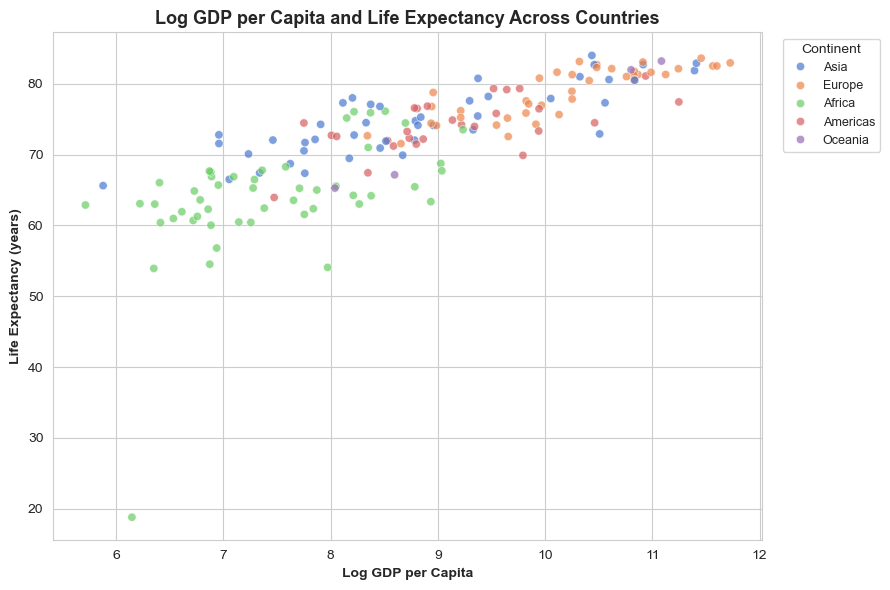

In [50]:
# Graph 1: log GDP per capita vs life expectancy by continent
import numpy as np
world_data['log_gdp'] = np.log(world_data['gdp_per_capita'])

sns.set_style('whitegrid')
plt.figure(figsize=(9, 6))
sns.scatterplot(x='log_gdp', y='life_expectancy', data=world_data,
                hue='continent', palette='muted', alpha=0.7)
plt.xlabel('Log GDP per Capita', fontweight='bold')
plt.ylabel('Life Expectancy (years)', fontweight='bold')
plt.title('Log GDP per Capita and Life Expectancy Across Countries', fontsize=13, fontweight='bold')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Continent', fontsize=9)
plt.tight_layout()
plt.show()

In [45]:
continent_map = {
    'AFG':'Asia','ALB':'Europe','DZA':'Africa','AGO':'Africa','ARG':'Americas',
    'ARM':'Asia','AUS':'Oceania','AUT':'Europe','AZE':'Asia','BHS':'Americas',
    'BHR':'Asia','BGD':'Asia','BLR':'Europe','BEL':'Europe','BLZ':'Americas',
    'BEN':'Africa','BTN':'Asia','BOL':'Americas','BIH':'Europe','BWA':'Africa',
    'BRA':'Americas','BRN':'Asia','BGR':'Europe','BFA':'Africa','BDI':'Africa',
    'CPV':'Africa','KHM':'Asia','CMR':'Africa','CAN':'Americas','CAF':'Africa',
    'TCD':'Africa','CHL':'Americas','CHN':'Asia','COL':'Americas','COM':'Africa',
    'COD':'Africa','COG':'Africa','CRI':'Americas','CIV':'Africa','HRV':'Europe',
    'CUB':'Americas','CYP':'Europe','CZE':'Europe','DNK':'Europe','DJI':'Africa',
    'DOM':'Americas','ECU':'Americas','EGY':'Africa','SLV':'Americas','GNQ':'Africa',
    'ERI':'Africa','EST':'Europe','SWZ':'Africa','ETH':'Africa','FJI':'Oceania',
    'FIN':'Europe','FRA':'Europe','GAB':'Africa','GMB':'Africa','GEO':'Asia',
    'DEU':'Europe','GHA':'Africa','GRC':'Europe','GTM':'Americas','GIN':'Africa',
    'GNB':'Africa','GUY':'Americas','HTI':'Americas','HND':'Americas','HUN':'Europe',
    'ISL':'Europe','IND':'Asia','IDN':'Asia','IRN':'Asia','IRQ':'Asia','IRL':'Europe',
    'ISR':'Asia','ITA':'Europe','JAM':'Americas','JPN':'Asia','JOR':'Asia',
    'KAZ':'Asia','KEN':'Africa','PRK':'Asia','KOR':'Asia','KWT':'Asia',
    'KGZ':'Asia','LAO':'Asia','LVA':'Europe','LBN':'Asia','LSO':'Africa',
    'LBR':'Africa','LBY':'Africa','LTU':'Europe','LUX':'Europe','MDG':'Africa',
    'MWI':'Africa','MYS':'Asia','MDV':'Asia','MLI':'Africa','MLT':'Europe',
    'MRT':'Africa','MUS':'Africa','MEX':'Americas','MDA':'Europe','MNG':'Asia',
    'MNE':'Europe','MAR':'Africa','MOZ':'Africa','MMR':'Asia','NAM':'Africa',
    'NPL':'Asia','NLD':'Europe','NZL':'Oceania','NIC':'Americas','NER':'Africa',
    'NGA':'Africa','MKD':'Europe','NOR':'Europe','OMN':'Asia','PAK':'Asia',
    'PAN':'Americas','PNG':'Oceania','PRY':'Americas','PER':'Americas','PHL':'Asia',
    'POL':'Europe','PRT':'Europe','QAT':'Asia','ROU':'Europe','RUS':'Europe',
    'RWA':'Africa','SAU':'Asia','SEN':'Africa','SRB':'Europe','SLE':'Africa',
    'SGP':'Asia','SVK':'Europe','SVN':'Europe','SOM':'Africa','ZAF':'Africa',
    'SSD':'Africa','ESP':'Europe','LKA':'Asia','SDN':'Africa','SUR':'Americas',
    'SWE':'Europe','CHE':'Europe','SYR':'Asia','TWN':'Asia','TJK':'Asia',
    'TZA':'Africa','THA':'Asia','TLS':'Asia','TGO':'Africa','TTO':'Americas',
    'TUN':'Africa','TUR':'Asia','TKM':'Asia','UGA':'Africa','UKR':'Europe',
    'ARE':'Asia','GBR':'Europe','USA':'Americas','URY':'Americas','UZB':'Asia',
    'VEN':'Americas','VNM':'Asia','YEM':'Asia','ZMB':'Africa','ZWE':'Africa'
}

#Mapping each country to its continent using ISO3 codes — this variable does not exist in the API
world_data['continent'] = world_data['countryiso3code'].map(continent_map)
world_data = world_data.dropna(subset=['continent'])
print(world_data['continent'].value_counts())

continent
Africa      52
Asia        46
Europe      40
Americas    28
Oceania      4
Name: count, dtype: int64


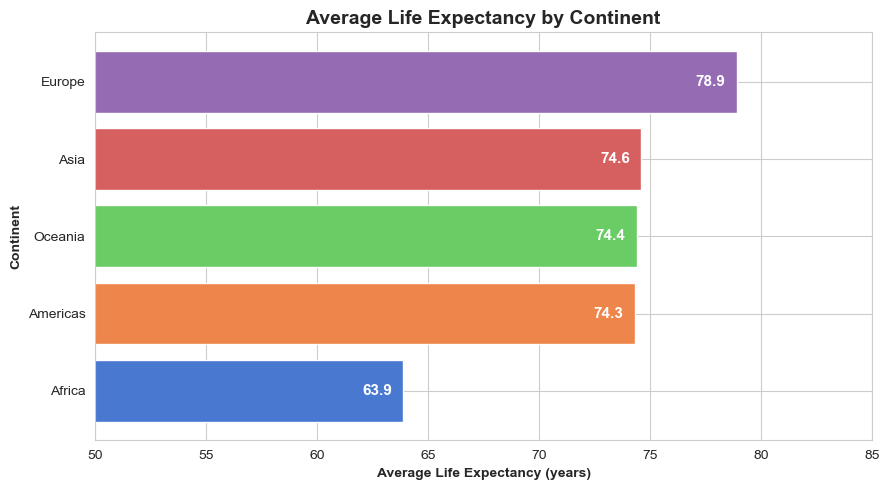

In [44]:
#Graph 2: Average life expectancy by continent
avg_le = world_data.groupby('continent')['life_expectancy'].mean().reset_index().sort_values('life_expectancy')

sns.set_style('whitegrid')
plt.figure(figsize=(9, 5))
bars = plt.barh(avg_le['continent'], avg_le['life_expectancy'],
                color=sns.color_palette('muted', len(avg_le)), edgecolor='white')

for bar in bars:
    plt.text(bar.get_width() - 0.5, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.1f}', va='center', ha='right',
             color='white', fontweight='bold', fontsize=11)

plt.xlabel('Average Life Expectancy (years)', fontweight='bold')
plt.ylabel('Continent', fontweight='bold')
plt.title('Average Life Expectancy by Continent', fontsize=14, fontweight='bold')
plt.xlim(50, 85)
plt.tight_layout()
plt.show()

# Europe and Oceania have the highest average life expectancy while Africa has the lowest.
# This aligns with known disparities in GDP and healthcare access across continents.

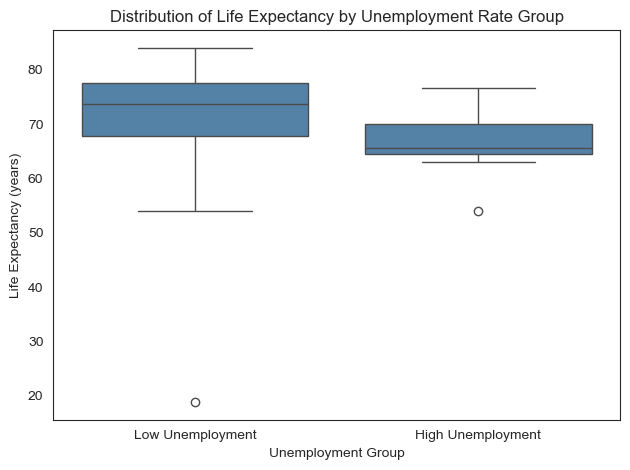

In [28]:
#Graph 3: Distribution of life expectancy by unemployment group
#Box plots show the full distribution, not just the average
#Source: https://r02b.github.io/seaborn_palettes/

#Splitting countries into two groups based on unemployment rate
#pd.cut divides a continuous variable into discrete bins— source: https://pandas.pydata.org/docs/reference/api/pandas.cut.html
world_data['unem_group'] = pd.cut(world_data['unemployment_rate'], bins=2, labels=['Low Unemployment', 'High Unemployment'])

#Setting the background style
sns.set_style('white')

#Creating a box plot: the spread and outliers of life expectancy within each unemployment group
ax = sns.boxplot(x='unem_group', y='life_expectancy', data=world_data, color='steelblue')

#Labeling the x axis
ax.set_xlabel('Unemployment Group')

#Labeling the y axis
ax.set_ylabel('Life Expectancy (years)')

#Adding the title
ax.set_title('Distribution of Life Expectancy by Unemployment Rate Group')

plt.tight_layout()
plt.show()

#Countries with lower unemployment tend to have higher and more consistent life expectancy.
#High unemployment countries show greater variation in life outcomes.

In [30]:
world_data.to_csv('world_data.csv')